📊 Перші рядки даних:
   CustomerID  Purchases  AvgPurchaseValue  RecencyDays
0           1         25                45           10
1           2          3               120          200
2           3         12                60           30
3           4          7                80          100
4           5         30                40            5


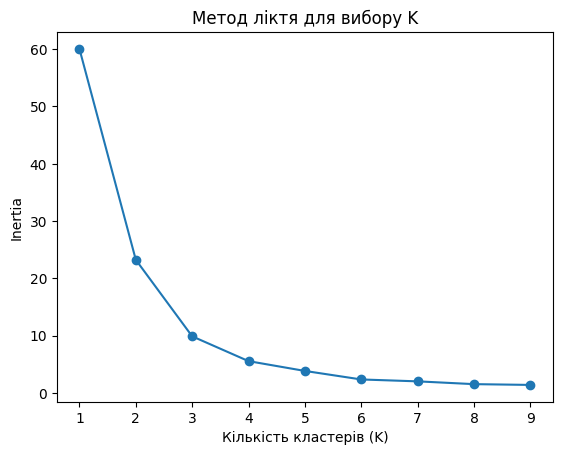


🔹 Кількість клієнтів у кожному кластері:
Cluster
2    9
0    7
1    4
Name: count, dtype: int64

🔹 Середні показники по кожному кластеру:
         Purchases  AvgPurchaseValue  RecencyDays
Cluster                                          
0             29.6              44.0          8.3
1              3.5             120.0        180.0
2             10.7              75.0         58.3


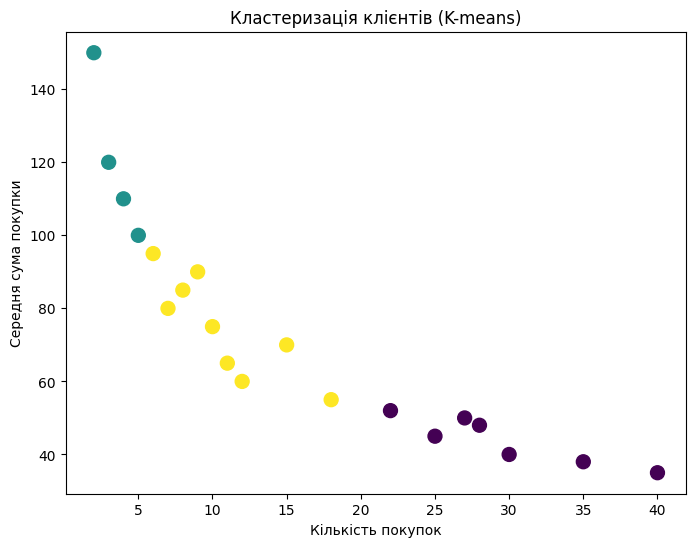


📈 Silhouette Score: 0.503


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = {
    'CustomerID': range(1, 21),
    'Purchases': [25, 3, 12, 7, 30, 18, 4, 40, 9, 15, 27, 2, 10, 35, 6, 22, 8, 11, 5, 28],
    'AvgPurchaseValue': [45, 120, 60, 80, 40, 55, 110, 35, 90, 70, 50, 150, 75, 38, 95, 52, 85, 65, 100, 48],
    'RecencyDays': [10, 200, 30, 100, 5, 20, 150, 2, 80, 60, 12, 250, 40, 8, 90, 15, 70, 35, 120, 6]
}

df = pd.DataFrame(data)

print("📊 Перші рядки даних:")
print(df.head())

features = ['Purchases', 'AvgPurchaseValue', 'RecencyDays']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title('Метод ліктя для вибору K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('Inertia')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n🔹 Кількість клієнтів у кожному кластері:")
print(df['Cluster'].value_counts())

print("\n🔹 Середні показники по кожному кластеру:")
print(df.groupby('Cluster')[features].mean().round(1))

plt.figure(figsize=(8,6))
plt.scatter(df['Purchases'], df['AvgPurchaseValue'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel('Кількість покупок')
plt.ylabel('Середня сума покупки')
plt.title('Кластеризація клієнтів (K-means)')
plt.show()

score = silhouette_score(X_scaled, df['Cluster'])
print(f"\n📈 Silhouette Score: {score:.3f}")


🔹 Мітки кластерів DBSCAN:
    CustomerID  Cluster_DB
0            1           0
1            2          -1
2            3           2
3            4           1
4            5           0
5            6           0
6            7          -1
7            8           0
8            9           1
9           10          -1
10          11           0
11          12          -1
12          13           2
13          14           0
14          15           1
15          16           0
16          17           1
17          18           2
18          19           1
19          20           0

🔹 Кількість клієнтів у кожному кластері:
Cluster_DB
 0    8
 1    5
-1    4
 2    3
Name: count, dtype: int64


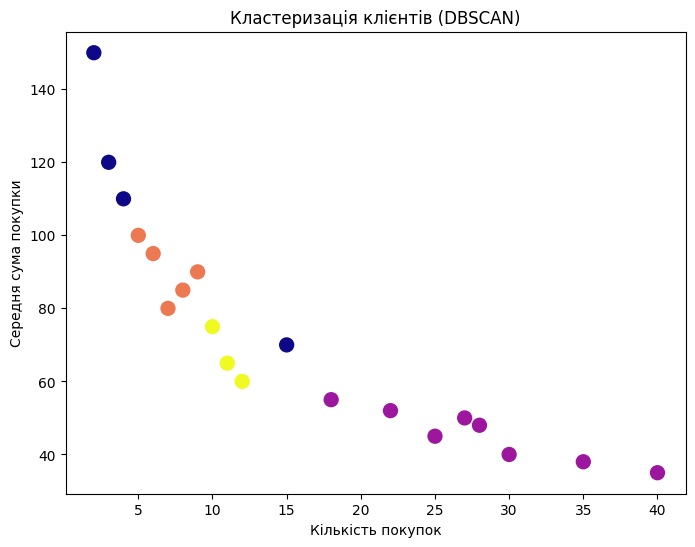

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

features = ['Purchases', 'AvgPurchaseValue', 'RecencyDays']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=3) 

df['Cluster_DB'] = dbscan.fit_predict(X_scaled)

print("\n🔹 Мітки кластерів DBSCAN:")
print(df[['CustomerID', 'Cluster_DB']])

print("\n🔹 Кількість клієнтів у кожному кластері:")
print(df['Cluster_DB'].value_counts())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df['Purchases'], df['AvgPurchaseValue'], c=df['Cluster_DB'], cmap='plasma', s=100)
plt.xlabel('Кількість покупок')
plt.ylabel('Середня сума покупки')
plt.title('Кластеризація клієнтів (DBSCAN)')
plt.show()